In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("coal_mines_balanced_300_rows.csv")
df.columns



Index(['mine_id', 'state', 'mine_type', 'coal_output_tons', 'energy_kwh',
       'pm25', 'so2', 'water_ph', 'water_tds', 'land_degradation_pct',
       'distance_forest_km', 'distance_river_km', 'env_risk_score',
       'carbon_emission_tons', 'shutdown_risk'],
      dtype='object')

In [ ]:
df.isnull().sum()



,0
mine_id,0
state,0
mine_type,0
coal_output_tons,0
energy_kwh,0
pm25,0
so2,0
water_ph,0
water_tds,0
land_degradation_pct,0


In [ ]:
df = df.drop_duplicates()


In [ ]:
df["water_ph"] = df["water_ph"].clip(5.5, 8.5)
df["land_degradation_pct"] = df["land_degradation_pct"].clip(0, 100)



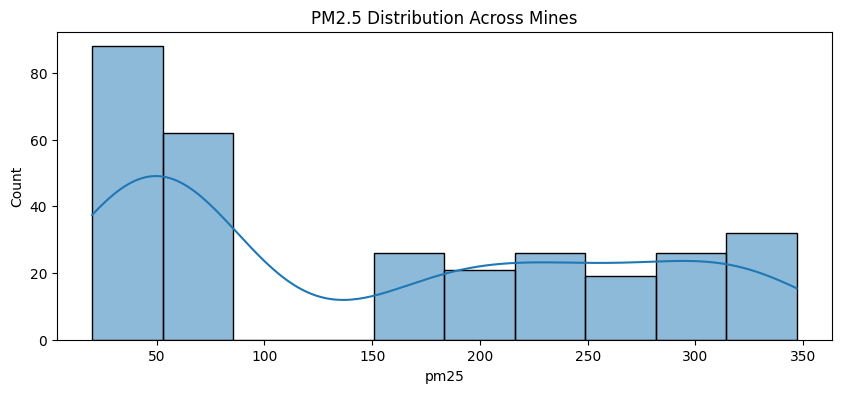

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(df["pm25"], kde=True)
plt.title("PM2.5 Distribution Across Mines")
plt.show()
#Shows air quality severity

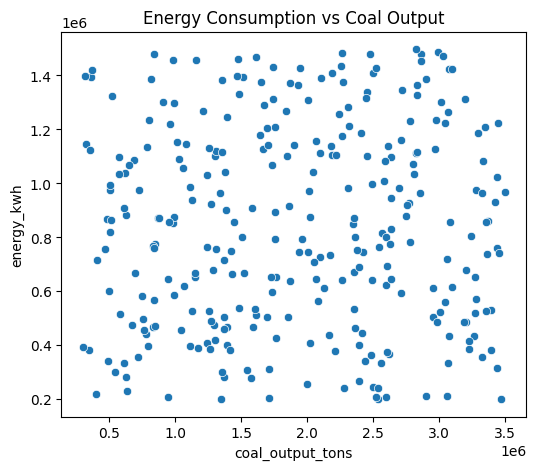

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df["coal_output_tons"],
    y=df["energy_kwh"]
)
plt.title("Energy Consumption vs Coal Output")
plt.show()
# Identifies inefficient mines

In [ ]:
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())


In [ ]:
air_risk = normalize(df["pm25"] + df["so2"])


In [ ]:
water_risk = normalize(abs(7 - df["water_ph"]) + df["water_tds"])


In [ ]:
land_risk = normalize(df["land_degradation_pct"])


In [ ]:
energy_risk = normalize(df["energy_kwh"])


In [ ]:
eco_risk = normalize(
    1 / (df["distance_forest_km"] + 0.1) +
    1 / (df["distance_river_km"] + 0.1)
)


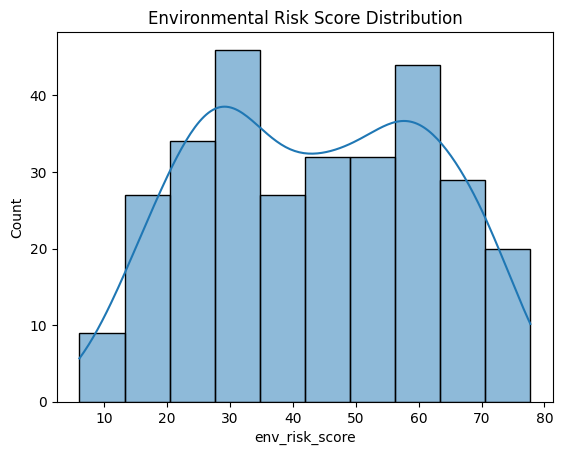

In [ ]:
df["env_risk_score"] = (
    0.30 * air_risk +
    0.25 * water_risk +
    0.20 * land_risk +
    0.15 * energy_risk +
    0.10 * eco_risk
) * 100
sns.histplot(df["env_risk_score"], bins=10, kde=True)
plt.title("Environmental Risk Score Distribution")
plt.show()


In [ ]:
df["carbon_emission_tons"] = (
    df["energy_kwh"] * 0.82 / 1000 +
    df["coal_output_tons"] * 0.08
)
#0.82 kg CO₂ per kWh
#0.08 tons CO₂ per ton of coal extracted

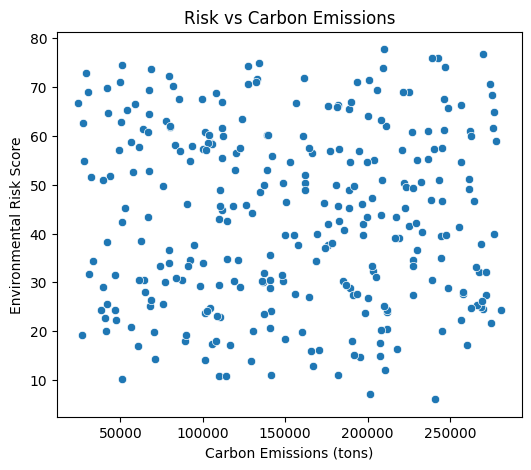

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df["carbon_emission_tons"],
    y=df["env_risk_score"]
)
plt.xlabel("Carbon Emissions (tons)")
plt.ylabel("Environmental Risk Score")
plt.title("Risk vs Carbon Emissions")
plt.show()


In [ ]:
def mine_decision(risk, carbon):
    if risk > 65 and carbon > 25000:
        return "Shut Down"
    else:
        return "Limited / Monitor"


In [ ]:
df["mine_status"] = df.apply(
    lambda row: mine_decision(
        row["env_risk_score"],
        row["carbon_emission_tons"]
    ),
    axis=1
)


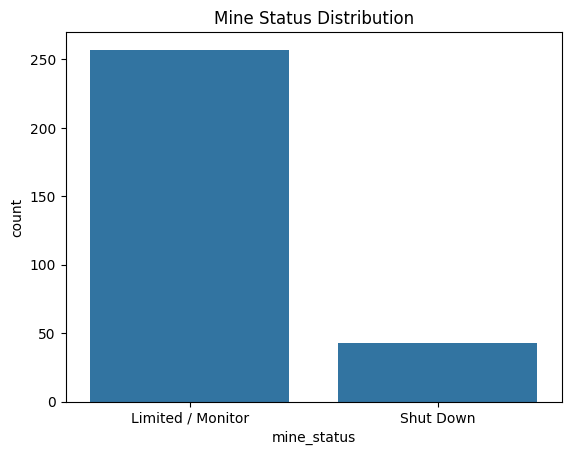

In [ ]:
sns.countplot(x=df["mine_status"])
plt.title("Mine Status Distribution")
plt.show()


In [ ]:
df["extraction_potential"] = (
    (100 - df["env_risk_score"]) * 0.6 +
    (df["coal_output_tons"] / df["coal_output_tons"].max()) * 40
)


In [ ]:
df["future_extraction_priority"] = pd.cut(
    df["extraction_potential"],
    bins=[0, 50, 100],
    labels=[
        "Not Suitable for Extraction",
        "Suitable for Extraction"
    ]
)


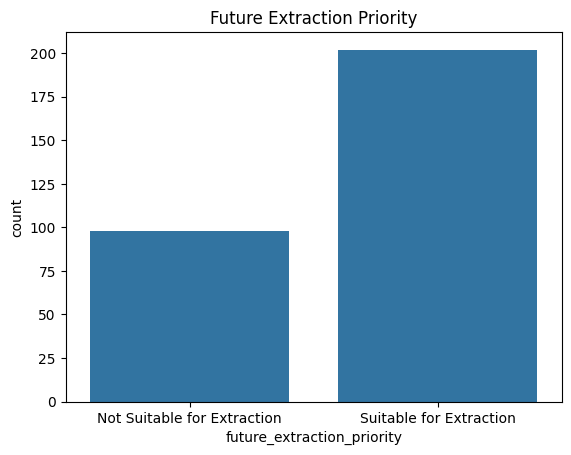

In [ ]:
sns.countplot(x=df["future_extraction_priority"])
plt.title("Future Extraction Priority")
plt.show()

In [ ]:
print(df["future_extraction_priority"].value_counts())

future_extraction_priority
Suitable for Extraction        202
Not Suitable for Extraction     98
Name: count, dtype: int64


In [ ]:

df.to_csv("final_coal_mine_decisions.csv", index=False)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_coal_mine_decisions.csv")
df["shutdown_risk"] = df["mine_status"].apply(
    lambda x: 1 if x == "Shut Down" else 0
)
X = df[
    [
        "pm25",
        "so2",
        "water_ph",
        "water_tds",
        "land_degradation_pct",
        "energy_kwh",
        "coal_output_tons",
        "distance_forest_km",
        "distance_river_km"
    ]
]

y = df["shutdown_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000,class_weight='balanced')

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)



In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.92      0.96        64
           1       0.69      1.00      0.81        11

    accuracy                           0.93        75
   macro avg       0.84      0.96      0.89        75
weighted avg       0.95      0.93      0.94        75



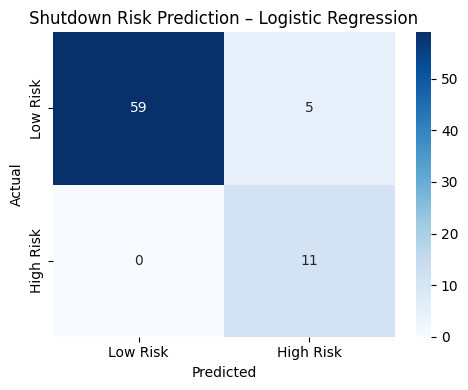

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Shutdown Risk Prediction – Logistic Regression")
plt.tight_layout()
plt.show()


In [ ]:
importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(ascending=False)


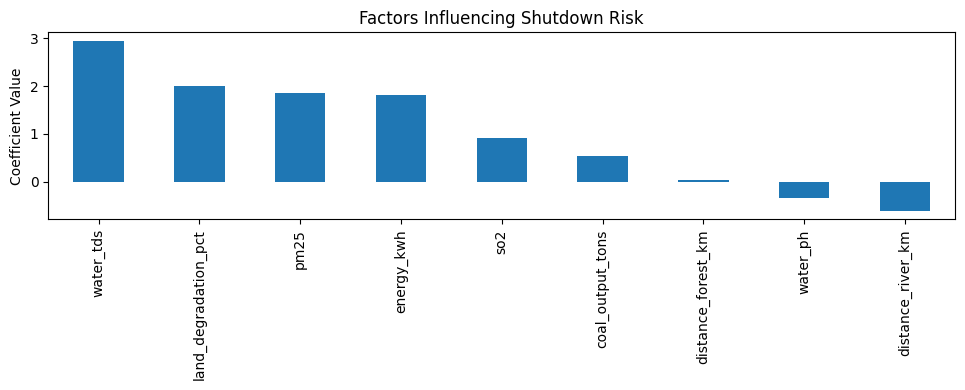

In [ ]:
importance.plot(kind="bar", figsize=(10,4))
plt.title("Factors Influencing Shutdown Risk")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()


In [ ]:
import joblib
new_mine = pd.DataFrame([{
    "pm25": 160,
    "so2": 95,
    "water_ph": 6.1,
    "water_tds": 1500,
    "land_degradation_pct": 55,
    "energy_kwh": 1550000,
    "coal_output_tons": 340000,
    "distance_forest_km": 1.3,
    "distance_river_km": 0.8
}])

new_mine_scaled = scaler.transform(new_mine)
prediction = model.predict(new_mine_scaled)

print("Shutdown Risk:", "High" if prediction[0] == 1 else "Low")

joblib.dump(model, "shutdown_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("shutdown_model.pkl and scaler.pkl created successfully.")


Shutdown Risk: Low
shutdown_model.pkl and scaler.pkl created successfully.


In [ ]:
import gradio as gr
import pandas as pd
import joblib

# Load trained model and scaler
model = joblib.load("shutdown_model.pkl")
scaler = joblib.load("scaler.pkl")

FEATURE_COLUMNS = [
    "pm25",
    "so2",
    "water_ph",
    "water_tds",
    "land_degradation_pct",
    "energy_kwh",
    "coal_output_tons",
    "distance_forest_km",
    "distance_river_km"
]

def predict_shutdown(
    pm25, so2, water_ph, water_tds,
    land_deg, energy_kwh, coal_output,
    forest_dist, river_dist
):
    # Create DataFrame with fixed column order
    input_data = pd.DataFrame([[
        pm25, so2, water_ph, water_tds,
        land_deg, energy_kwh, coal_output,
        forest_dist, river_dist
    ]], columns=FEATURE_COLUMNS)

    # Scale
    input_scaled = scaler.transform(input_data)

    # Probability (correct way)
    probability = float(model.predict_proba(input_scaled)[0][1])

    # Decision based on probability
    status = (
        "🚨 HIGH SHUTDOWN RISK"
        if probability >= 0.6
        else "✅ LOW SHUTDOWN RISK"
    )

    return status, f"{probability*100:.2f}%"

# Gradio Interface
interface = gr.Interface(
    fn=predict_shutdown,
    inputs=[
        gr.Number(label="PM2.5 (µg/m³)"),
        gr.Number(label="SO₂ (µg/m³)"),
        gr.Number(label="Water pH"),
        gr.Number(label="Water TDS"),
        gr.Number(label="Land Degradation (%)"),
        gr.Number(label="Energy Consumption (kWh)"),
        gr.Number(label="Coal Output (tons)"),
        gr.Number(label="Distance to Forest (km)"),
        gr.Number(label="Distance to River (km)")
    ],
    outputs=[
        gr.Textbox(label="Shutdown Risk Status"),
        gr.Textbox(label="Shutdown Probability")
    ],
    title="🌍 Coal Mine Shutdown Risk Predictor",
    description="Predicts environmental shutdown risk using air, water, land, and carbon indicators."
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b21f726475f020d302.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import os
os.kill(os.getpid(), 9)
